In [104]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from plotly import figure_factory as FF
from plotly.offline import iplot

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans,DBSCAN,AgglomerativeClustering
from sklearn.metrics import silhouette_score,davies_bouldin_score
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn import preprocessing,cluster

from scipy.stats import kurtosis,skew,pearsonr
from scipy.cluster.hierarchy import linkage, dendrogram

from yellowbrick.cluster import KElbowVisualizer

from collections import Counter
from warnings import simplefilter
plt.rcParams['font.family'] = 'DejaVu Sans'
simplefilter("ignore")

In [105]:
data = pd.read_csv("dataset/Mall_Customers.csv")

data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [106]:
print(f'Number of Null: {data.isnull().sum().sum()}.')

Number of Null: 0.


In [107]:
print(f'Number of duplicate data: {data.duplicated().sum()}.')

Number of duplicate data: 0.


In [108]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [109]:
data.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [110]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


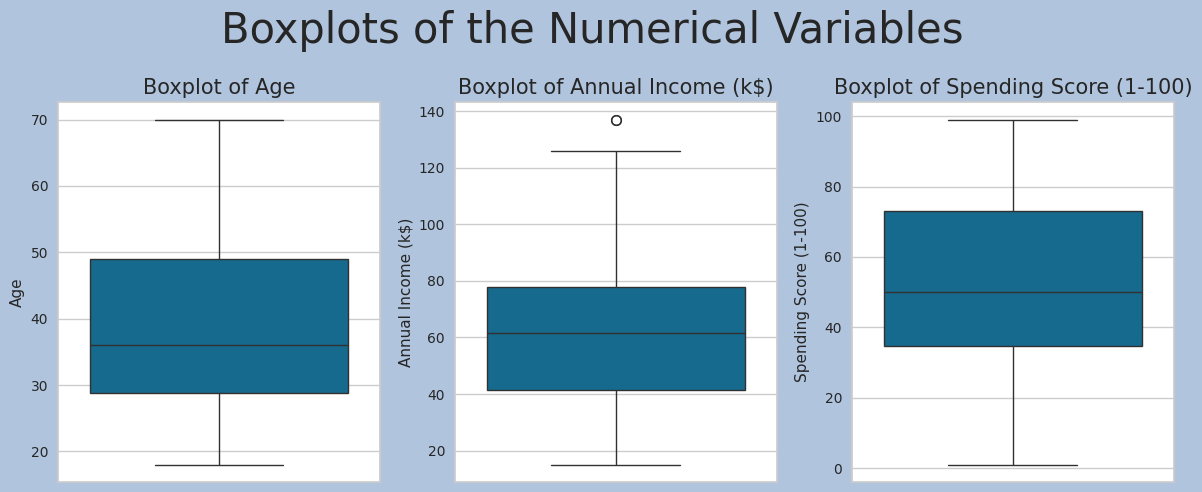

In [111]:
features = ['Age','Annual Income (k$)','Spending Score (1-100)']

fig,(ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(12,5))

ax1 = sns.boxplot(data[features[0]],ax=ax1)
ax1.set_title('Boxplot of '+str(features[0]),fontsize=15)

ax2 = sns.boxplot(data[features[1]],ax=ax2)
ax2.set_title('Boxplot of '+str(features[1]),fontsize=15)

ax3 = sns.boxplot(data[features[2]],ax=ax3)
ax3.set_title('Boxplot of '+str(features[2]),fontsize=15)

fig.suptitle("Boxplots of the Numerical Variables",fontsize=30)

plt.tight_layout()
fig.set_facecolor('lightsteelblue')


In [112]:
outliers_perc = []

for k,v in data[features].items():
    # Column must be of numeric type (not object)
    if data[k].dtype != 'O':
        q1 = v.quantile(0.25)
        q3 = v.quantile(0.75)
        irq = q3 - q1
        v_col = v[(v <= q1 - 1.5 * irq) | (v >= q3 + 1.5 * irq)]
        perc = np.shape(v_col)[0] * 100.0 / np.shape(data)[0]
        out_tuple = (k,int(perc))
        outliers_perc.append(out_tuple)
        print("Column %s outliers = %.2f%%" % (k,perc))

Column Age outliers = 0.00%
Column Annual Income (k$) outliers = 1.00%
Column Spending Score (1-100) outliers = 0.00%


# Exploratory Data Analysis (EDA)

In [113]:
num_features = ['Age','Annual Income (k$)','Spending Score (1-100)']

for col in num_features:

    print(f"Skewness of {col}: {skew(data[col])}")
    print(f"Kurtosis of {col}: {kurtosis(data[col])}")
    print()

Skewness of Age: 0.48191947090957177
Kurtosis of Age: -0.6847513947723236

Skewness of Annual Income (k$): 0.319423684276314
Kurtosis of Annual Income (k$): -0.1258928297475106

Skewness of Spending Score (1-100): -0.04686530945553505
Kurtosis of Spending Score (1-100): -0.8359582718737237



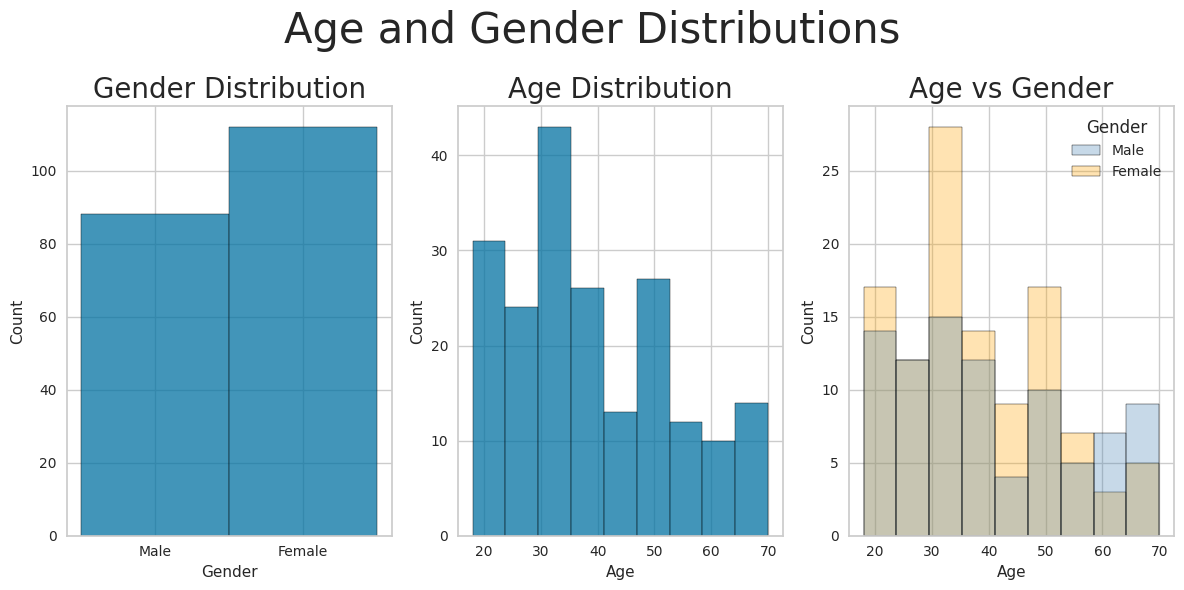

In [114]:
fig,(ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(12,6))

ax1 = sns.histplot(data=data,x='Gender',ax=ax1)
ax1.set_title('Gender Distribution',size=20)

ax2 = sns.histplot(data=data,x='Age',ax=ax2)
ax2.set_title('Age Distribution',size=20)

ax3 = sns.histplot(data=data,x='Age',hue='Gender',palette=['steelblue','orange'],alpha=0.3,ax=ax3)
ax3.set_title('Age vs Gender',size=20)

plt.suptitle('Age and Gender Distributions',size=30)

plt.tight_layout()

In [115]:
print(f"Females: {data['Gender'].value_counts()[0] / len(data) * 100:.0f}% \
      Males: {data['Gender'].value_counts()[1] / len(data) * 100:.0f}%")

Females: 56%       Males: 44%


In [116]:
print(f"Average age = {data['Age'].mean():.0f} +/- {data['Age'].std():.0f}")

print(f"Average age females = {data.loc[data.Gender == 'Female']['Age'].mean():.0f} +/- {data.loc[data.Gender == 'Female']['Age'].std():.0f}")

print(f"Average age males = {data.loc[data.Gender == 'Male']['Age'].mean():.0f} +/- {data.loc[data.Gender == 'Male']['Age'].std():.0f}")

Average age = 39 +/- 14
Average age females = 38 +/- 13
Average age males = 40 +/- 16


In [117]:
###########################################
age_bins = [18,31,44,57,74]
age_labels = [f"{i}-{i+14}" for i in range(18,74,14)]
data['ageGroups'] = pd.cut(data['Age'],bins=age_bins,labels=age_labels,right=False)
###########################################

data['ageGroups'].value_counts()

ageGroups
32-46    67
18-32    62
46-60    43
60-74    28
Name: count, dtype: int64

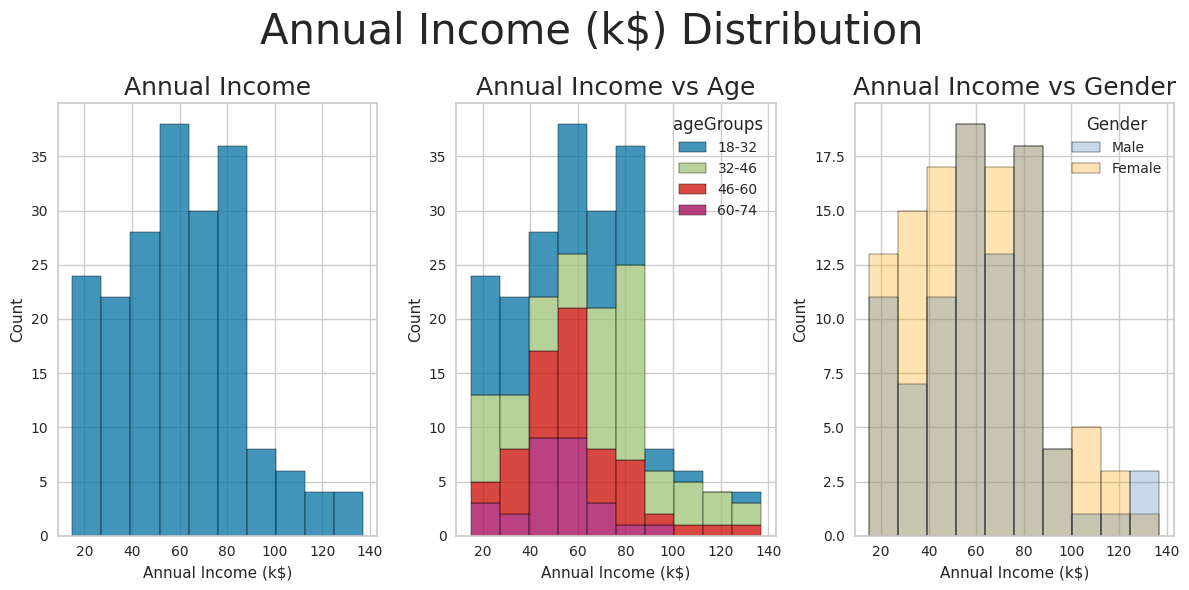

In [118]:
fig,(ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(12,6))

ax1 = sns.histplot(data=data,x='Annual Income (k$)',ax=ax1)
ax1.set_title('Annual Income',size=18)

ax2 = sns.histplot(data=data,x='Annual Income (k$)',hue='ageGroups',multiple="stack",ax=ax2)
ax2.set_title('Annual Income vs Age',size=18)

ax3 = sns.histplot(data=data,x='Annual Income (k$)',hue='Gender',palette=['steelblue','orange'],alpha=0.3,ax=ax3)
ax3.set_title('Annual Income vs Gender',size=18)

plt.suptitle('Annual Income (k$) Distribution',size=30)

plt.tight_layout()

In [119]:
data.groupby('ageGroups')['Annual Income (k$)'].mean()

ageGroups
18-32    55.209677
32-46    69.208955
46-60    59.860465
60-74    52.785714
Name: Annual Income (k$), dtype: float64

<Figure size 1200x600 with 0 Axes>

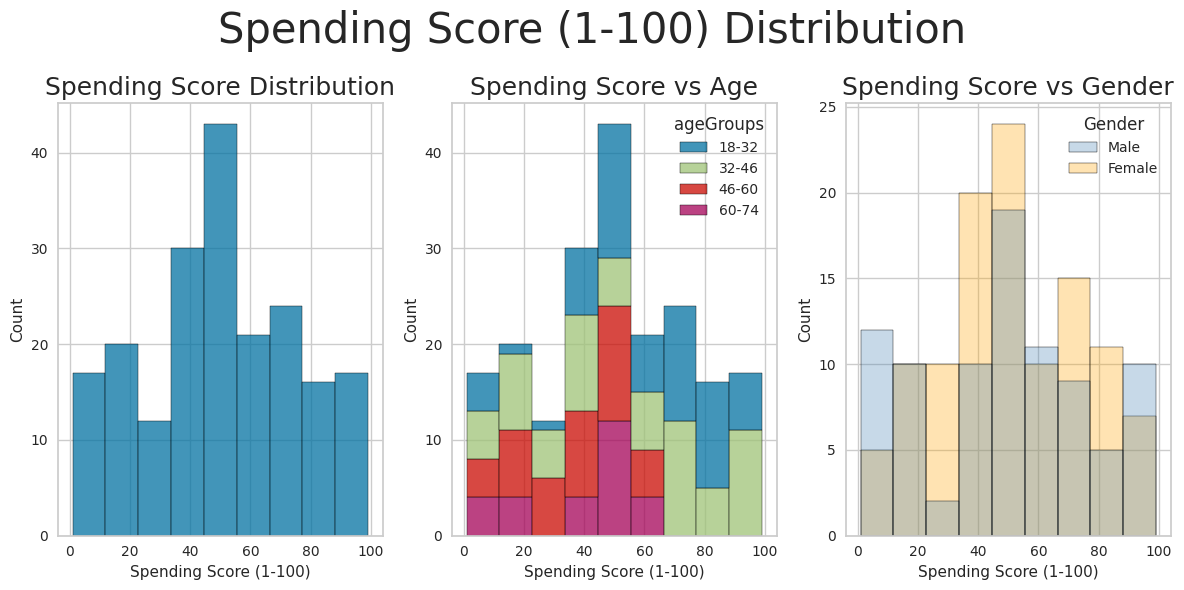

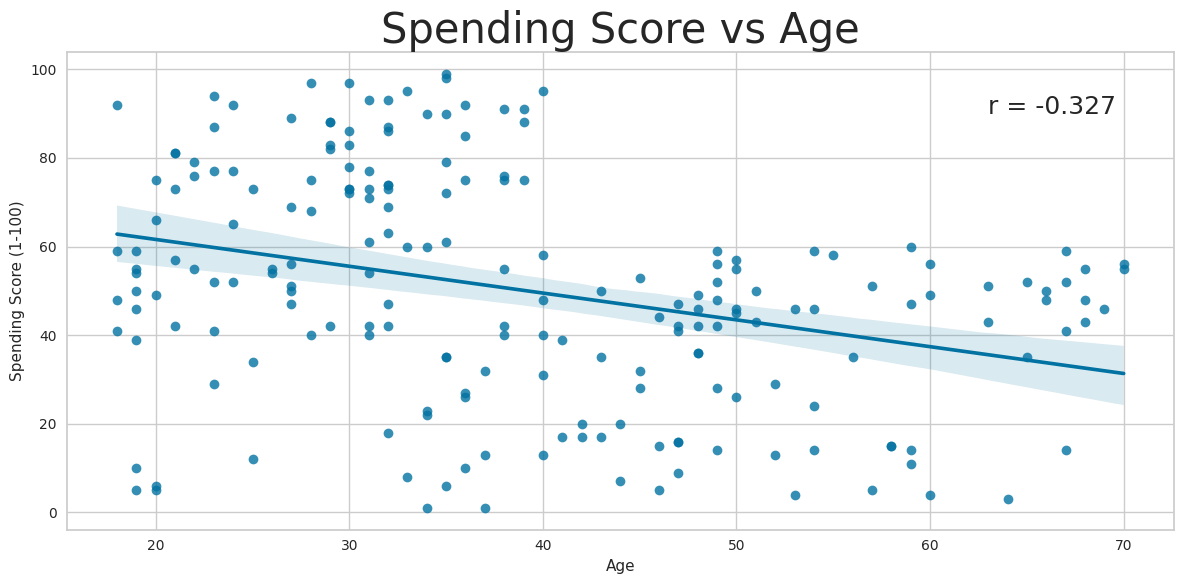

In [120]:
### Correlation: Spending Score vs Age ###

# Convert dataframe into series
list1 = data['Age']
list2 = data['Spending Score (1-100)']

# Apply the pearsonr()
corr, _ = pearsonr(list1,list2)


fig = plt.figure(figsize=(12,6))
(topfig,bottomfig) = fig.subfigures(2,1)

topfig.subplots_adjust(left=.1,right=.9,wspace=.1,hspace=.1)

fig,(ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(12,6))

ax1 = sns.histplot(data=data,x='Spending Score (1-100)',ax=ax1)
ax1.set_title('Spending Score Distribution',size=18)

ax2 = sns.histplot(data=data,x='Spending Score (1-100)',hue='ageGroups',multiple="stack",ax=ax2)
ax2.set_title('Spending Score vs Age',size=18)

ax3 = sns.histplot(data=data,x='Spending Score (1-100)',hue='Gender',palette=['steelblue','orange'],alpha=0.3,ax=ax3)
ax3.set_title('Spending Score vs Gender',size=18)

plt.suptitle('Spending Score (1-100) Distribution',size=30)

plt.tight_layout()

bottomfig.subplots_adjust(left=.1,right=.9,wspace=.1,hspace=.1)

ax = plt.figure(figsize=(12,6))

ax = sns.regplot(data=data,x='Age',y='Spending Score (1-100)')
ax.set_title('Spending Score vs Age',size=30)
ax.text(63,90,f"r = {corr:.3f}",size=18)

plt.tight_layout()

In [121]:
data.groupby('ageGroups')['Spending Score (1-100)'].mean()

ageGroups
18-32    61.032258
32-46    54.402985
46-60    35.651163
60-74    38.500000
Name: Spending Score (1-100), dtype: float64

In [122]:
data.groupby('Gender')['Spending Score (1-100)'].mean()

Gender
Female    51.526786
Male      48.511364
Name: Spending Score (1-100), dtype: float64

# Data Engineering

In [123]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),ageGroups
0,1,Male,19,15,39,18-32
1,2,Male,21,15,81,18-32
2,3,Female,20,16,6,18-32
3,4,Female,23,16,77,18-32
4,5,Female,31,17,40,32-46


In [124]:
data2 = data.drop(['CustomerID'],axis=1)

data2.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),ageGroups
0,Male,19,15,39,18-32
1,Male,21,15,81,18-32
2,Female,20,16,6,18-32
3,Female,23,16,77,18-32
4,Female,31,17,40,32-46


In [125]:
encoder = LabelEncoder()

data2['Gender'] = encoder.fit_transform(data2['Gender'])

data2.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),ageGroups
0,1,19,15,39,18-32
1,1,21,15,81,18-32
2,0,20,16,6,18-32
3,0,23,16,77,18-32
4,0,31,17,40,32-46


In [126]:
#data2_sc = data2.drop('ageGroups',axis=1)
data2_sc = data2.drop(['ageGroups','Gender'],axis=1)

scaler = StandardScaler()

scaled_columns = data2_sc.columns

data2_sc[scaled_columns] = scaler.fit_transform(data2_sc[scaled_columns])

data2_sc.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


# Clustering (K-Mean)

In [127]:
# Create an empty list to hold many inertia values
inertia_values = []

range_clusters = range(2,16)

# Create 2 - 15 clusters, and add the inertia scores to the list
for k in range_clusters:
    kmeans = KMeans(n_clusters=k,n_init=10,random_state=42)
    kmeans.fit(data2_sc)
    inertia_values.append(kmeans.inertia_)

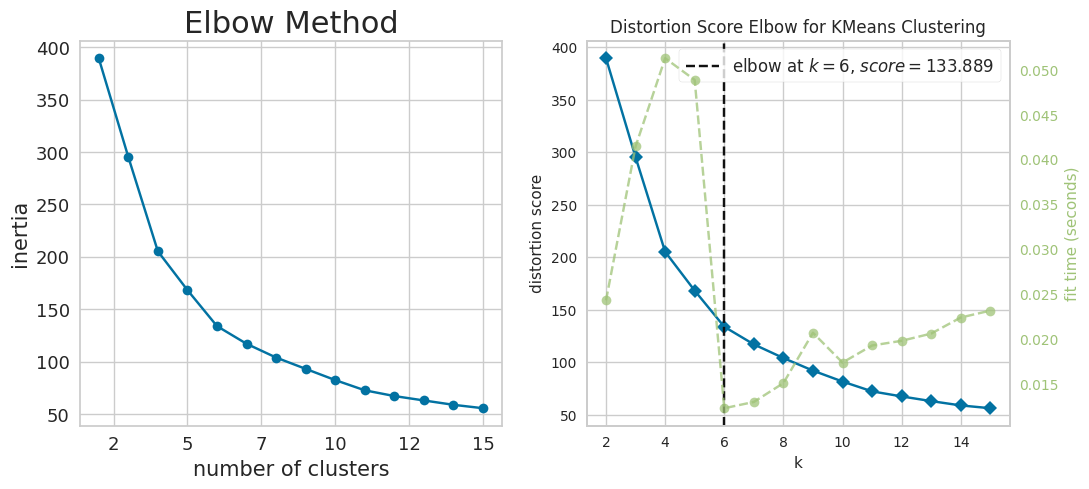

<Figure size 800x550 with 0 Axes>

In [128]:
features = data2_sc.columns

fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

# First Plot
ax1.plot(range_clusters,inertia_values,marker='o',linestyle='-')
ax1.xaxis.set_tick_params(labelsize=13)
ax1.set_xticklabels(ax1.get_xticks().astype(int))
ax1.yaxis.set_tick_params(labelsize=13)
ax1.set_xlabel("number of clusters",fontsize=15)
ax1.set_ylabel('inertia',fontsize=15)
ax1.set_title("Elbow Method",fontsize=22)

# Second Plot
Elbow_M = KElbowVisualizer(KMeans(),k=15)
Elbow_M.fit(data2_sc[features])
ax2 = Elbow_M.show()

plt.tight_layout() 

In [129]:
davies_bouldin_scores = []

for i in range_clusters:
    kmeans = KMeans(n_clusters=i,random_state=42)
    labels = kmeans.fit_predict(data2_sc)
    score = davies_bouldin_score(data2_sc,labels)
    davies_bouldin_scores.append(score)

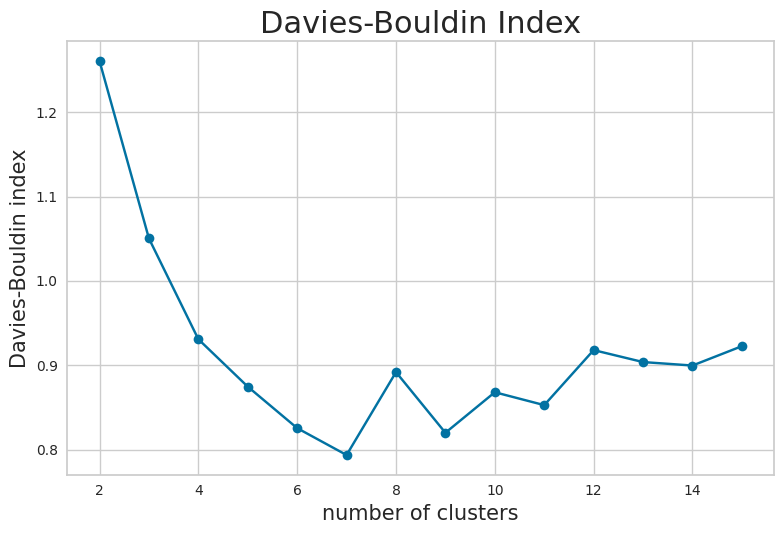

In [130]:
plt.plot(range_clusters,davies_bouldin_scores,marker='o')
plt.xlabel("number of clusters",fontsize=15)
plt.ylabel('Davies-Bouldin index',fontsize=15)
plt.title("Davies-Bouldin Index",fontsize=22)

plt.tight_layout()
plt.show()

In [131]:
silhouette_scores = []

for i in range_clusters:
    kmeans = KMeans(n_clusters=i,random_state=42)
    labels = kmeans.fit_predict(data2_sc) 
    score = silhouette_score(data2_sc,labels)
    silhouette_scores.append(score)

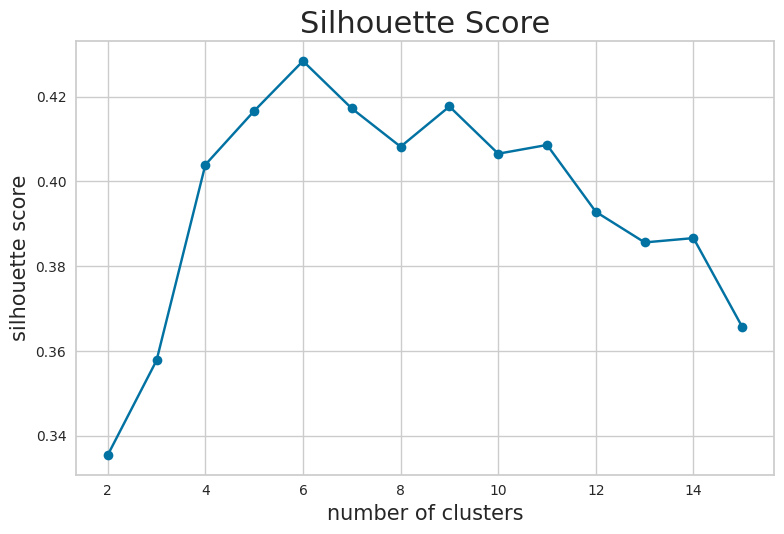

In [132]:
plt.plot(range_clusters,silhouette_scores,marker='o')
plt.xlabel("number of clusters",fontsize=15)
plt.ylabel('silhouette score',fontsize=15)
plt.title("Silhouette Score",fontsize=22)

plt.tight_layout()
plt.show()

In [133]:
def plot_clusters(k,data2,LABELS):

    # Initiating KMeans. n_clusters = k
    km = KMeans(n_clusters=k,n_init=10,random_state=42)

    # Fit model and predict clusters
    yhat = km.fit_predict(data2[LABELS])
    data2[f"{k}_clusters_2D"] = yhat

    # Adding the Clusters feature to the dataframe before encoding and scaling
    data[f"{k}_clusters_2D"] = yhat

    # Initiating PCA to reduce dimentions to 2
    pca = PCA(n_components=2,random_state=42)

    pca.fit(data2[LABELS]) 
    data_sc_2D = pd.DataFrame(pca.transform(data2[LABELS]),columns=(["col1","col2"]))
    data_sc_2D["clusters_2D"] = yhat

    cluster_count = data_sc_2D.groupby("clusters_2D")["clusters_2D"].count().reset_index(name='count').sort_values(by='count',ascending=False)

    print(cluster_count)

    ### Figures ###
    bigfig = plt.figure(figsize=(12,6))

    (top,bottom) = bigfig.subfigures(2,1)

    ### Top figure ###
    top.subplots_adjust(left=.1,right=.9,wspace=.4,hspace=.4)

    k_cluster_data = pd.DataFrame(km.cluster_centers_,columns=LABELS)

    ax = plt.figure(figsize=(12,6))
    
    ax = sns.heatmap(data=k_cluster_data,cmap='RdBu',annot=True)
    ax.set_title('Cluster Centers',fontsize=15)

    plt.suptitle(f'{k} Clusters Case',size=30)

    plt.tight_layout()

    ### Bottom figure ###
    bottom.subplots_adjust(left=.1,right=.9,wspace=.4,hspace=.4)
    fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,6))

    ax1 = sns.barplot(x='clusters_2D',y='count',data=cluster_count,palette='Spectral',ax=ax1)
    ax1.set_xlabel("cluster number",fontsize=15)
    ax1.set_ylabel('count',fontsize=15)
    ax1.set_title(f"Numerical Distribution of the Clusters",fontsize=15)

    ax2 = sns.scatterplot(x="col1",y="col2",data=data_sc_2D,hue="clusters_2D",palette='Spectral',ax=ax2)
    ax2.set_title("2D Representation of the Clusters",fontsize=15)
    legend_handles,_ = ax2.get_legend_handles_labels()

    plt.tight_layout()

   clusters_2D  count
2            2     91
0            0     68
1            1     41


<Figure size 1200x600 with 0 Axes>

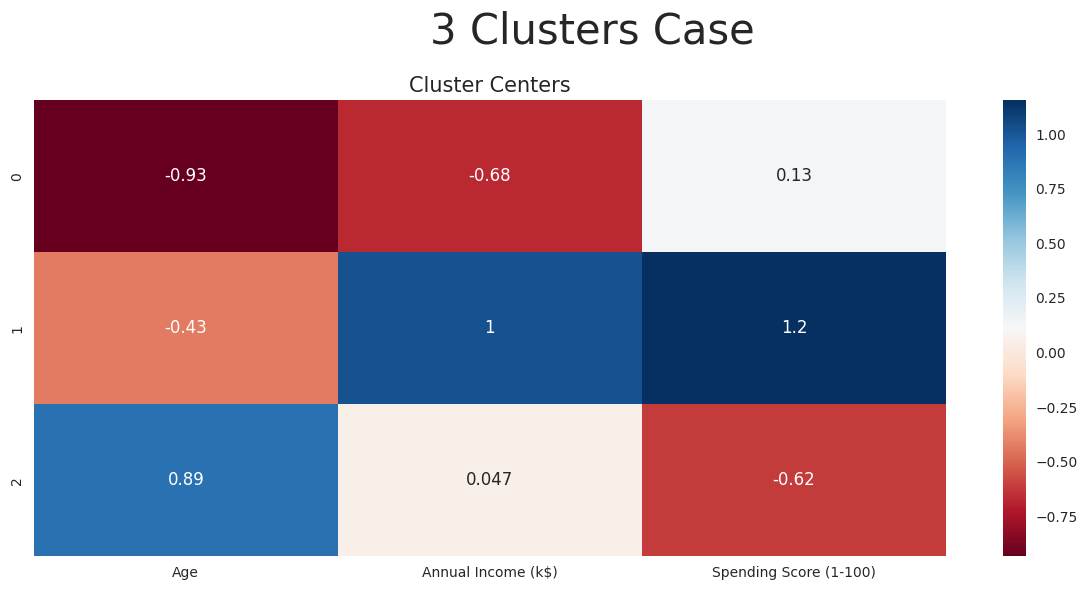

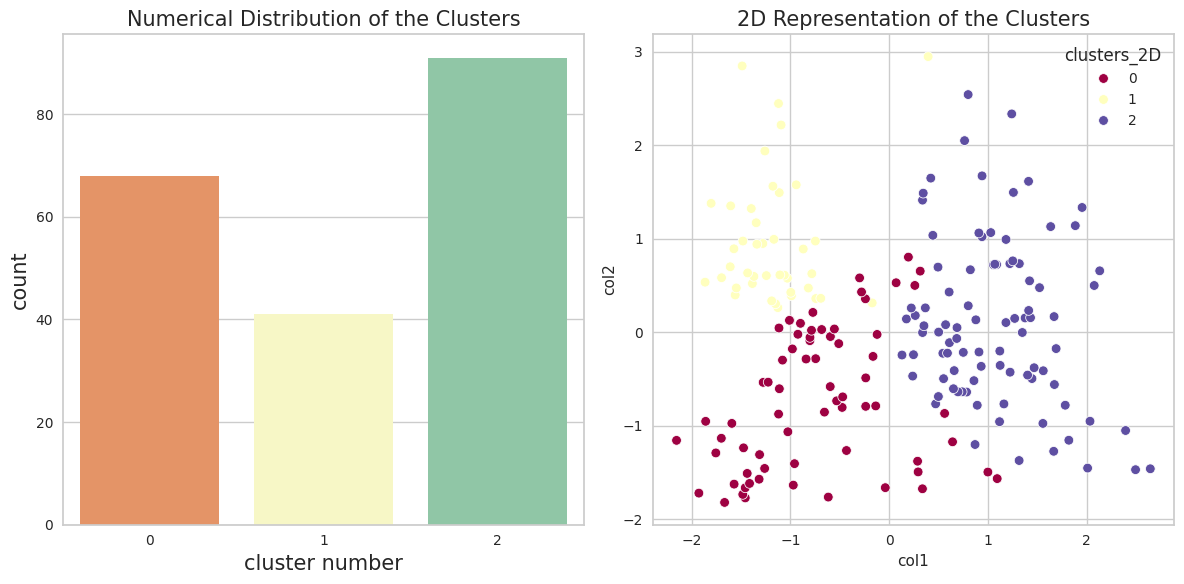

In [134]:
#LABELS2 = ['Gender','Age','Annual Income (k$)','Spending Score (1-100)']
LABELS2 = ['Age','Annual Income (k$)','Spending Score (1-100)']

plot_clusters(3,data2_sc,LABELS2)

   clusters_2D  count
0            0     65
2            2     57
1            1     40
3            3     38


<Figure size 1200x600 with 0 Axes>

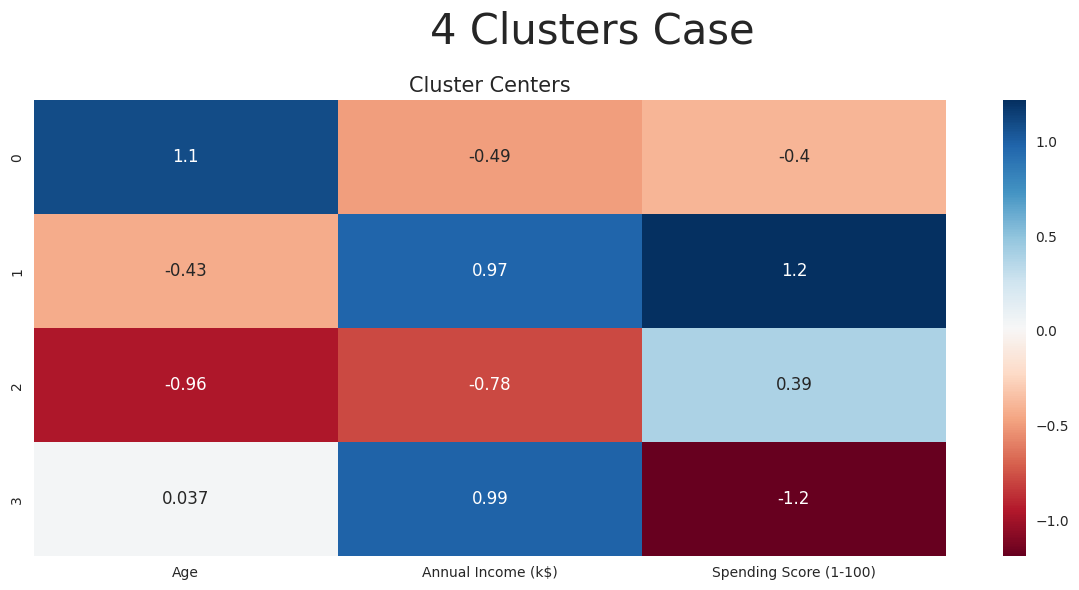

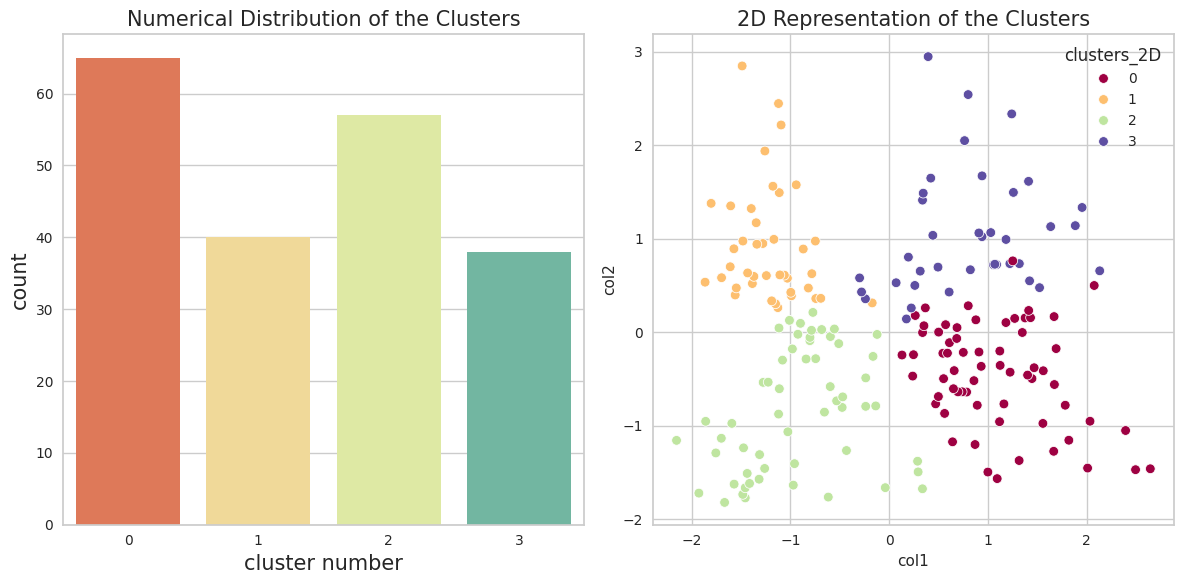

In [135]:
plot_clusters(4,data2_sc,LABELS2)

   clusters_2D  count
1            1     54
4            4     47
2            2     40
3            3     39
0            0     20


<Figure size 1200x600 with 0 Axes>

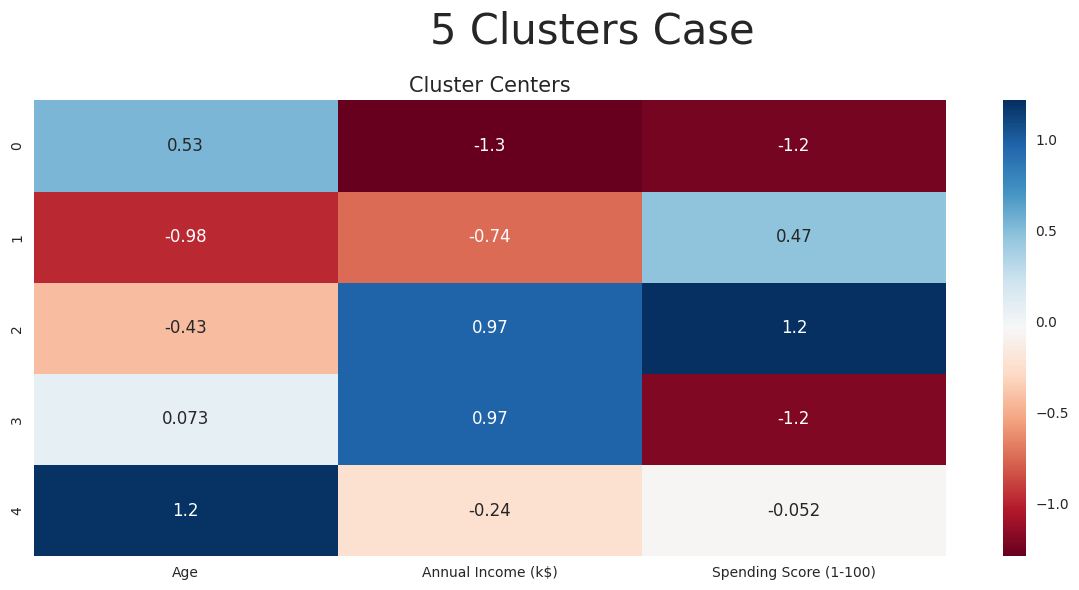

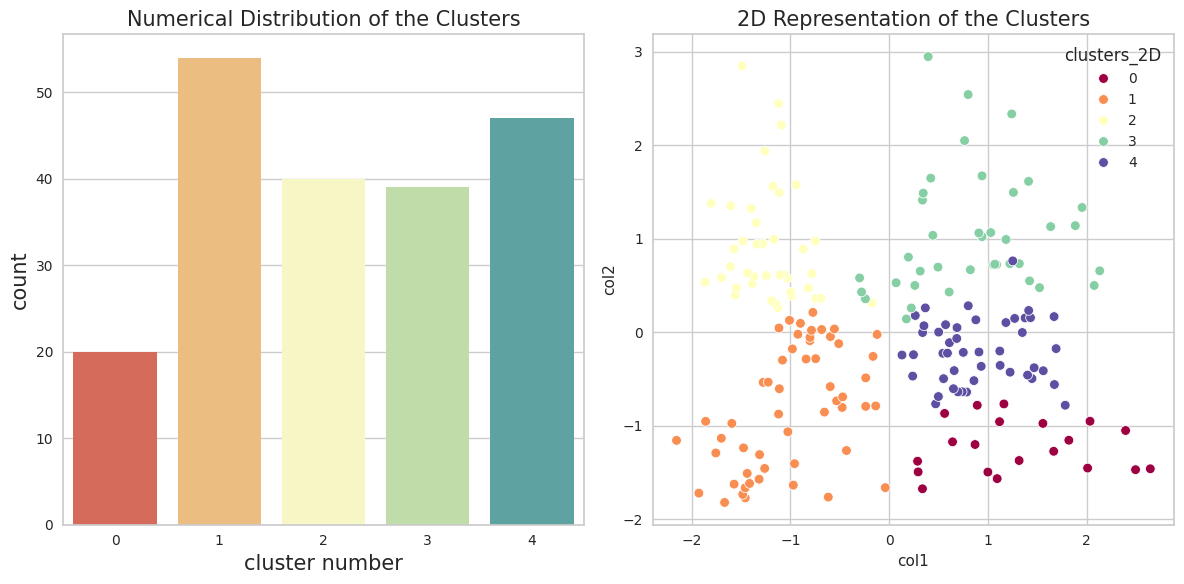

In [136]:
plot_clusters(5,data2_sc,LABELS2)

   clusters_2D  count
0            0     45
1            1     39
3            3     39
2            2     33
4            4     23
5            5     21


<Figure size 1200x600 with 0 Axes>

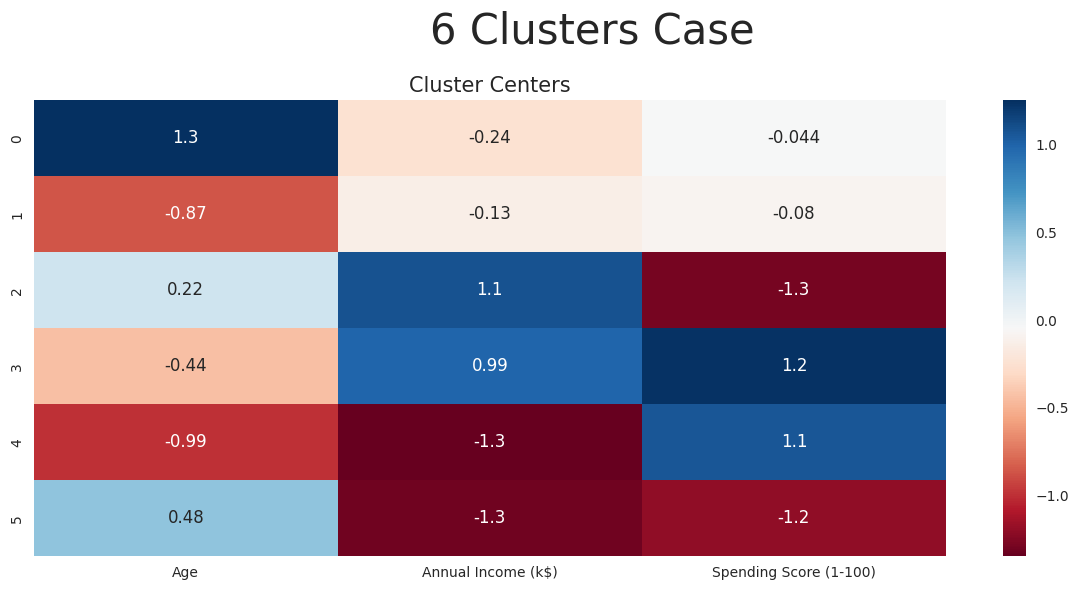

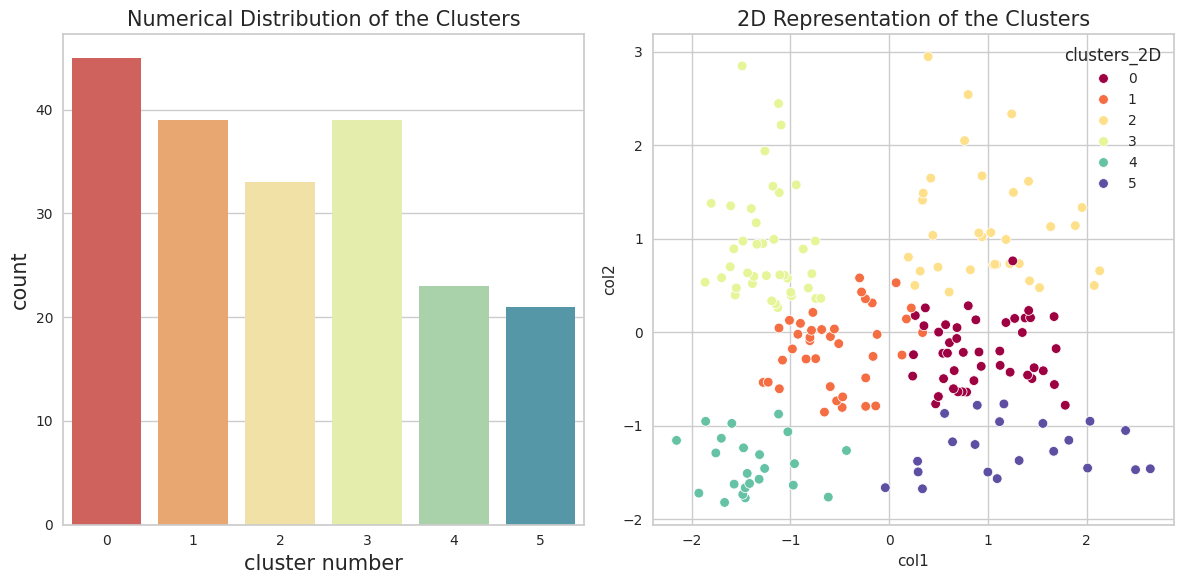

In [137]:
plot_clusters(6,data2_sc,LABELS2)

## Interpreting the PCA Output

In [138]:
# Initiating PCA to reduce dimentions to 2
pca = PCA(n_components=2,random_state=42)

pca.fit(data2_sc[LABELS2]) 
data2_pca = pd.DataFrame(pca.transform(data2_sc[LABELS2]),columns=(["col1","col2"]))

data2_pca.head()

,col1,col2
0,-0.615720,-1.763481
1,-1.665793,-1.820747
2,0.337862,-1.674799
3,-1.456573,-1.772430
4,-0.038465,-1.662740


In [139]:
pca.explained_variance_ratio_

array([0.44266167, 0.33308378])

In [140]:
pca.components_

array([[ 0.70638235, -0.04802398, -0.70619946],
       [ 0.03014116,  0.9988316 , -0.03777499]])

In [141]:
data2_sc[LABELS2].columns

Index(['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

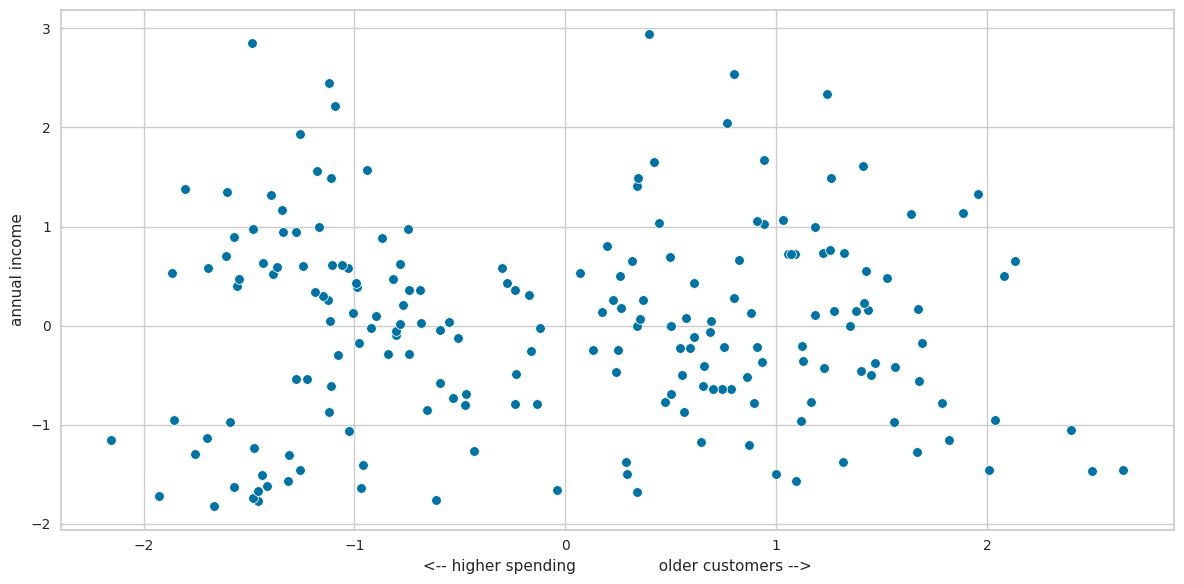

In [142]:
plt.figure(figsize=(12,6))

sns.scatterplot(x='col1',y='col2',data=data2_pca)

plt.xlabel('<-- higher spending                 older customers -->')
plt.ylabel('annual income')

plt.tight_layout()

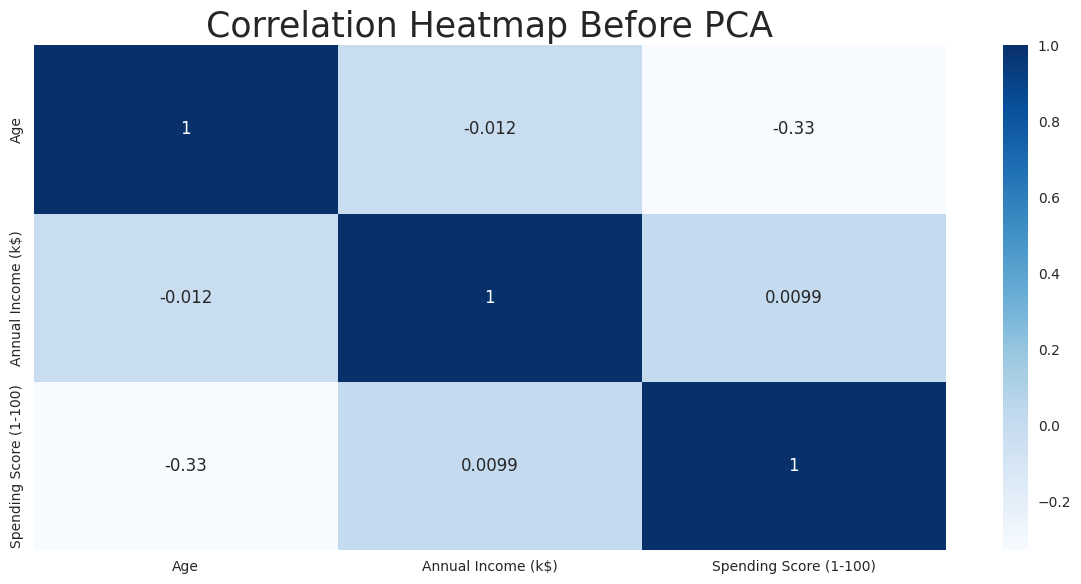

In [143]:
# Create correlation heatmap
plt.figure(figsize=(12,6))
sns.heatmap(data2_sc[['Age','Annual Income (k$)','Spending Score (1-100)']].corr(method='pearson'),annot=True,cmap='Blues')
plt.title('Correlation Heatmap Before PCA',fontsize=25)

plt.tight_layout()
plt.show()

# Clustering (Hyerarchical)

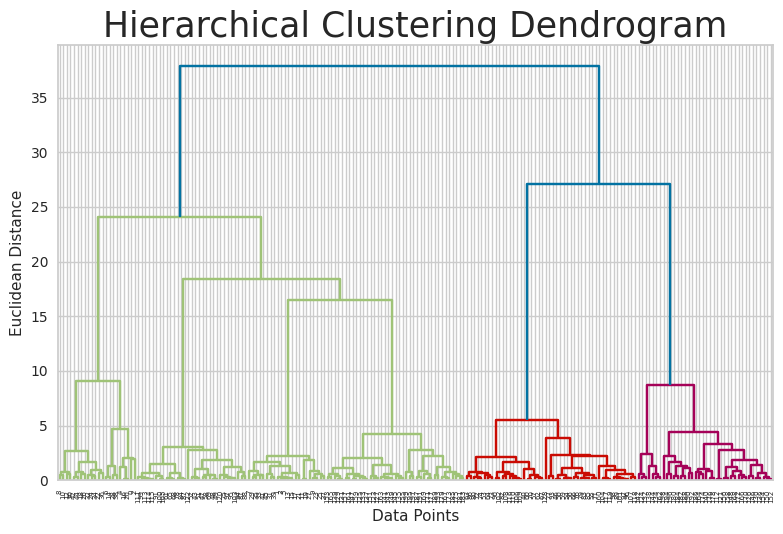

In [144]:
data3_sc = data2_sc.drop(['3_clusters_2D','4_clusters_2D','5_clusters_2D','6_clusters_2D'],axis=1)

linkage_matrix = linkage(data2_sc,method='ward')
dendrogram_info = dendrogram(linkage_matrix)

plt.title("Hierarchical Clustering Dendrogram",size=25)
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")

plt.tight_layout()

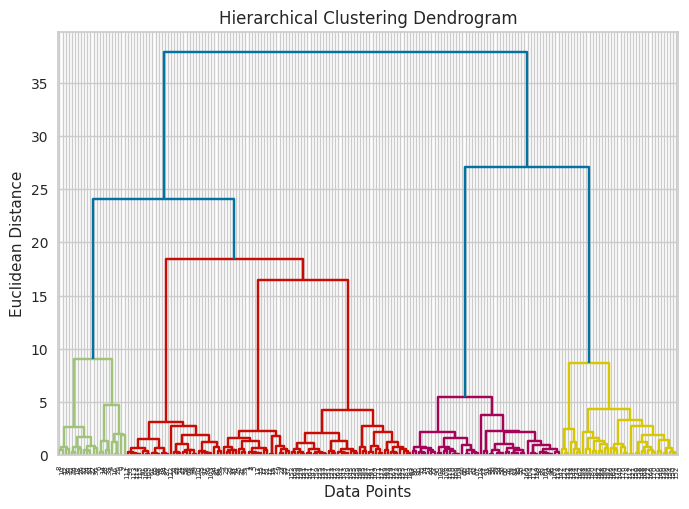

In [145]:
# Visually identify the ”best” number of clusters and adjust the color_threshold
linkage_matrix = linkage(data2_sc,method='ward')
dendrogram_info = dendrogram(linkage_matrix,color_threshold=20)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance");

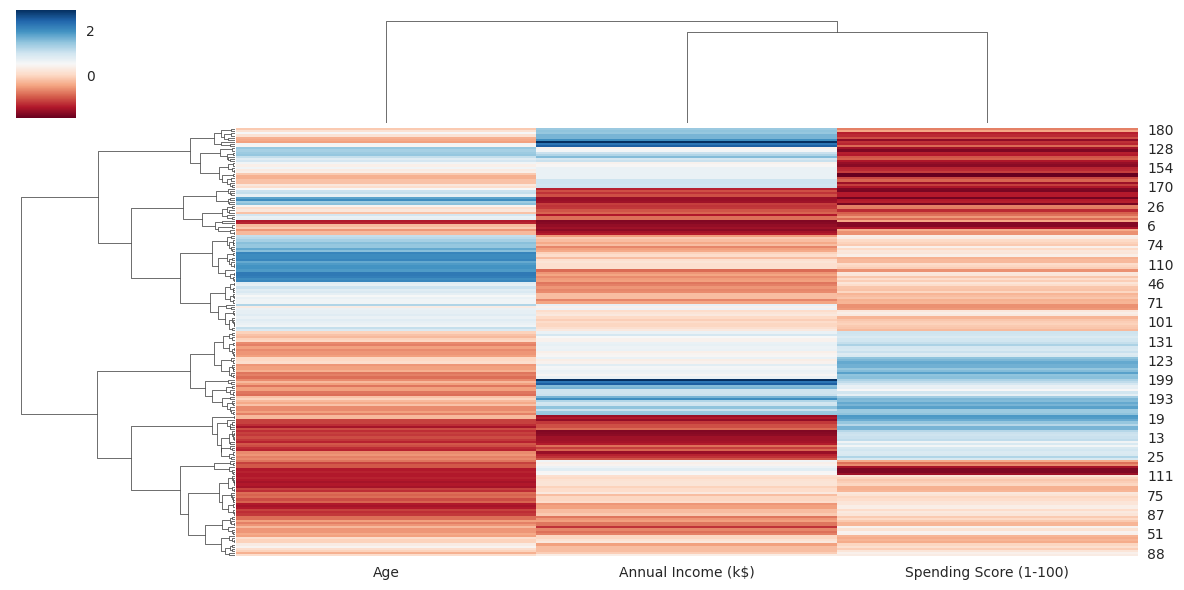

In [146]:
# create a cluster map
clustermap = sns.clustermap(data3_sc,method='ward',cmap='RdBu',figsize=(12,6),xticklabels=data3_sc.columns)
plt.show()

In [147]:
agg_4Cl = AgglomerativeClustering(4)
agg_4Cl.fit(data3_sc)

print(Counter(agg_4Cl.labels_))

silhouette_score(data3_sc,agg_4Cl.labels_)

Counter({0: 67, 1: 66, 2: 39, 3: 28})


0.3614512741691407

In [148]:
# hierarchical clustering with sklearn, with 5 clusters
agg = AgglomerativeClustering(5)
agg.fit(data3_sc)

print(Counter(agg.labels_))

Counter({0: 66, 1: 45, 2: 39, 3: 28, 4: 22})


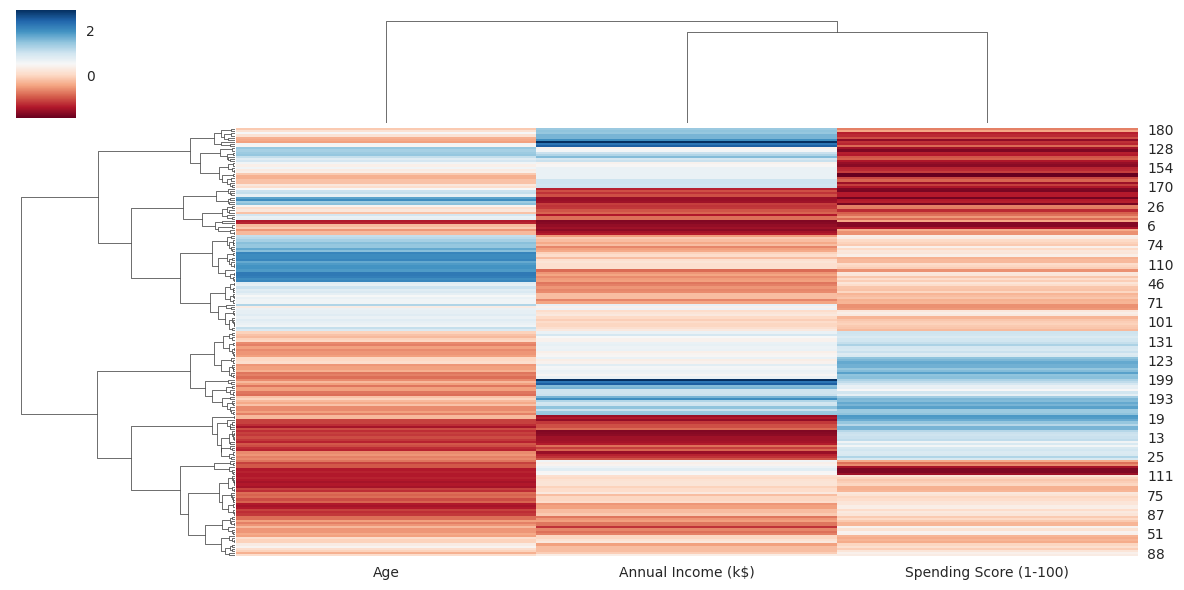

In [149]:
# create a cluster map
clustermap = sns.clustermap(data3_sc,method='ward',cmap='RdBu',figsize=(12,6),xticklabels=data3_sc.columns)
plt.show()

In [150]:
agg_5Cl = AgglomerativeClustering(5)
agg_5Cl.fit(data3_sc)

print(Counter(agg_5Cl.labels_))

silhouette_score(data3_sc,agg_5Cl.labels_)

Counter({0: 66, 1: 45, 2: 39, 3: 28, 4: 22})


0.39002826186267214

In [151]:
# hierarchical clustering with sklearn, with 6 clusters
agg = AgglomerativeClustering(6)
agg.fit(data3_sc)

print(Counter(agg.labels_))

Counter({0: 45, 1: 45, 2: 39, 3: 28, 4: 22, 5: 21})


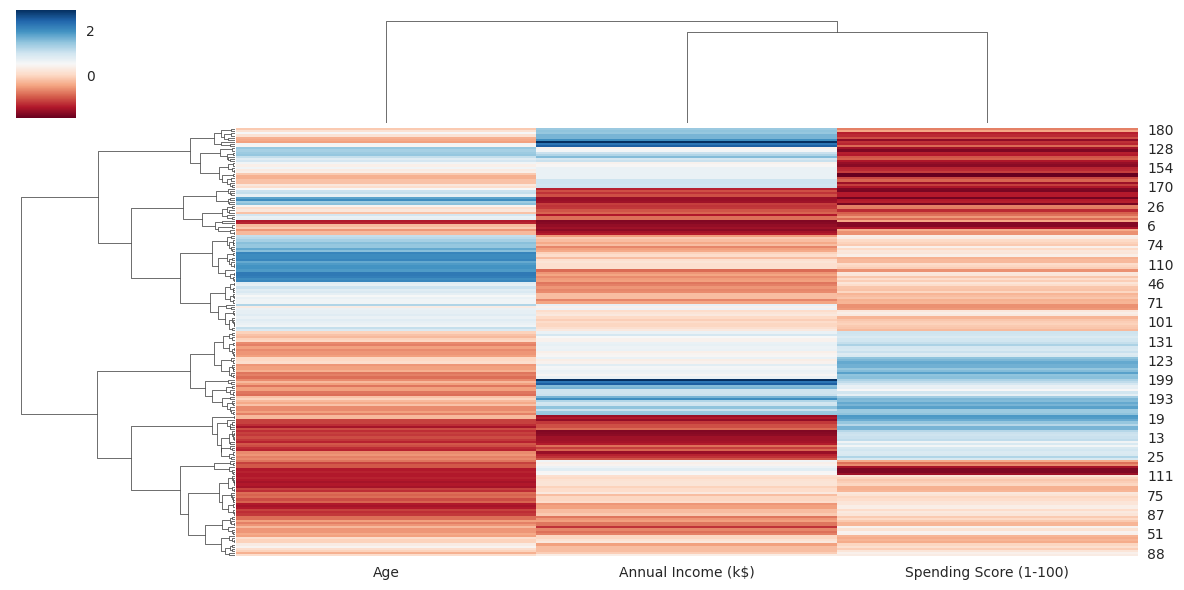

In [152]:
# create a cluster map
clustermap = sns.clustermap(data3_sc,method='ward',cmap='RdBu',figsize=(12,6),xticklabels=data3_sc.columns)
plt.show()

In [153]:
agg_6Cl = AgglomerativeClustering(6)
agg_6Cl.fit(data3_sc)

print(Counter(agg_6Cl.labels_))

silhouette_score(data3_sc,agg_6Cl.labels_)

Counter({0: 45, 1: 45, 2: 39, 3: 28, 4: 22, 5: 21})


0.4201169558789579

# Customer Personas

In [154]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),ageGroups,3_clusters_2D,4_clusters_2D,5_clusters_2D,6_clusters_2D
0,1,Male,19,15,39,18-32,0,2,1,4
1,2,Male,21,15,81,18-32,0,2,1,4
2,3,Female,20,16,6,18-32,0,2,0,5
3,4,Female,23,16,77,18-32,0,2,1,4
4,5,Female,31,17,40,32-46,0,2,1,5


In [155]:
data.groupby('6_clusters_2D').agg(gender=('Gender',lambda x: x.value_counts().index[0]),
                       age=('Age','mean'),
                       income=('Annual Income (k$)','mean'),
                       spending_score=('Spending Score (1-100)','mean')).reset_index()

,6_clusters_2D,gender,age,income,spending_score
0,0,Female,56.333333,54.266667,49.066667
1,1,Female,26.794872,57.102564,48.128205
2,2,Male,41.939394,88.939394,16.969697
3,3,Female,32.692308,86.538462,82.128205
4,4,Female,25.000000,25.260870,77.608696
5,5,Female,45.523810,26.285714,19.380952


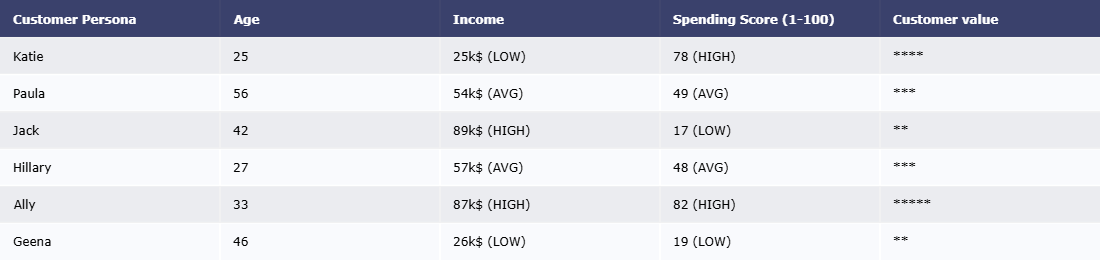

In [156]:
table_data = [['Customer Persona', 'Age', 'Income', 'Spending Score (1-100)', 'Customer value'],
             ['Katie', 25, '25k$ (LOW)', '78 (HIGH)', '****'],
             ['Paula', 56, '54k$ (AVG)', '49 (AVG)', '***'],
             ['Jack', 42, '89k$ (HIGH)', '17 (LOW)', '**'],
             ['Hillary', 27, '57k$ (AVG)', '48 (AVG)', '***'],              
             ['Ally', 33, '87k$ (HIGH)', '82 (HIGH)', '*****'],              
             ['Geena', 46, '26k$ (LOW)', '19 (LOW)', '**']]

# Initialize a figure with FF.create_table(table_data)
figure = FF.create_table(table_data,height_constant=30)
figure.layout.width=1500

iplot(figure)

# Model Predictions

In [157]:
# new customers for prediction
ID_201 = pd.DataFrame({'CustomerID':[201],'Gender':'Female','Age':39,'Annual Income (k$)':35,'Spending Score (1-100)':45})

ID_202 = pd.DataFrame({'CustomerID':[202],'Gender':'Male','Age':29,'Annual Income (k$)':55,'Spending Score (1-100)':65})

ID_201.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,201,Female,39,35,45


In [158]:
ID_202.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,202,Male,29,55,65


In [159]:
ID_201 = ID_201.drop(['CustomerID','Gender'],axis=1)
ID_202 = ID_202.drop(['CustomerID','Gender'],axis=1)

scaled_columns = data3_sc.columns

ID_201[scaled_columns] = scaler.transform(ID_201[scaled_columns])
ID_202[scaled_columns] = scaler.transform(ID_202[scaled_columns])

Text(0.5, 1.0, 'Cluster Centers')

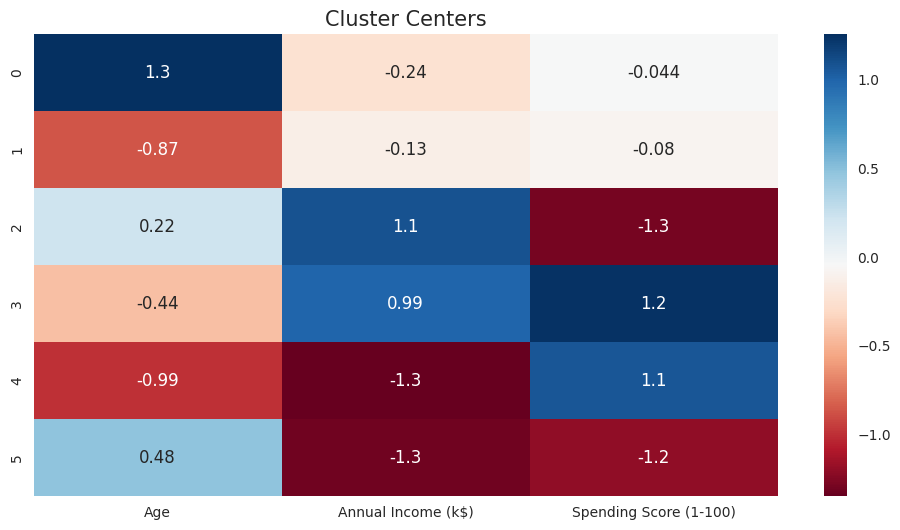

In [160]:
# Initiating KMeans. n_clusters = 6
km6 = KMeans(n_clusters=6,n_init=10,random_state=42)

# Fit model and predict clusters
yhat = km6.fit_predict(data3_sc[scaled_columns])
data3_sc[f"{k}_clusters_2D"] = yhat

# As a remainder, plot the a heatmap of the cluster centers
six_cluster_data = pd.DataFrame(km6.cluster_centers_,columns=scaled_columns)

ax = plt.figure(figsize=(12,6))
ax = sns.heatmap(data=six_cluster_data,cmap='RdBu',annot=True)
ax.set_title('Cluster Centers',fontsize=15)